*  DSC540-T301 Data Preparation
*  Final Project: Milestone V 
*  Jeremy Hunt

# Part 1: Database Creation & SQL Merging

In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# --- STEP 1: Load the 3 Cleaned Datasets We Created Previously ---
df_csv = pd.read_csv('cleaned_movie_metadata.csv')
df_web = pd.read_csv('cleaned_web_data.csv')
df_api = pd.read_csv('cleaned_api_data.csv')

# --- STEP 2: Create SQLite Database and Load Tables ---
# This creates a file called 'hollywood_project.db' in your folder
conn = sqlite3.connect('hollywood_project.db')

# Load the dataframes into the database as individual tables
df_csv.to_sql('movies_csv', conn, if_exists='replace', index=False)
df_web.to_sql('movies_web', conn, if_exists='replace', index=False)
df_api.to_sql('movies_api', conn, if_exists='replace', index=False)
print("Data successfully loaded into SQLite database tables.")

# --- STEP 3: The SQL JOIN ---
# We will use a LEFT JOIN starting from our largest table (the CSV)
# joining on our cleaned key: 'movie_title'
query = """
    SELECT 
        c.movie_title,
        c.director,
        c.budget_millions,
        c.gross_revenue_csv,
        c.imdb_score,
        c.roi,
        w.gross_revenue_wiki,
        w.rank as wiki_all_time_rank,
        a.mpaa_rating,
        a.runtime_minutes,
        a.rotten_tomatoes,
        a.primary_genre
    FROM movies_csv c
    LEFT JOIN movies_api a ON c.movie_title = a.movie_title
    LEFT JOIN movies_web w ON c.movie_title = w.movie_title
"""

# Execute the query and load the combined data back into a Pandas DataFrame
master_df = pd.read_sql_query(query, conn)

# Close the database connection
conn.close()

print(f"SQL Join Complete! The master dataset has {len(master_df)} rows and {len(master_df.columns)} columns.")

Data successfully loaded into SQLite database tables.
SQL Join Complete! The master dataset has 3859 rows and 12 columns.


# Part 2: The 5 Visualizations

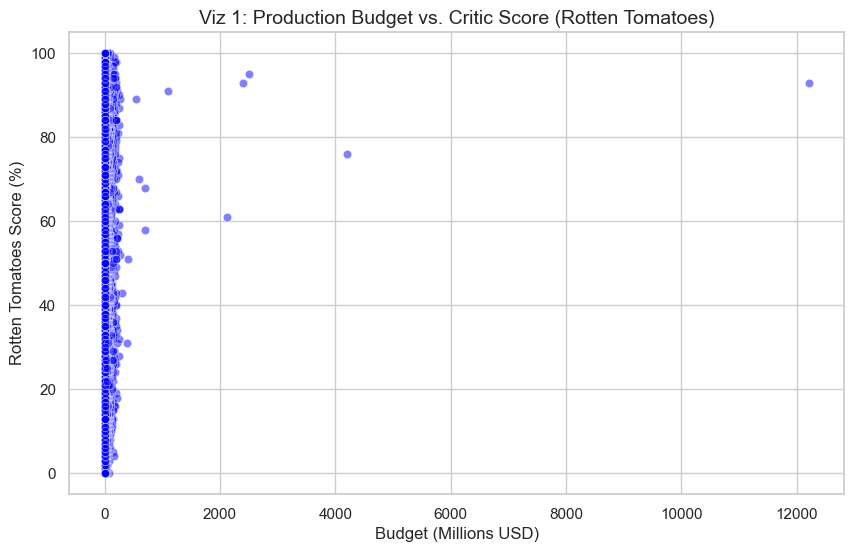

In [3]:
# Set the visual theme for all charts
sns.set_theme(style="whitegrid")

# =========================================================
# Visualization 1: Budget (CSV) vs. Rotten Tomatoes (API)
# Type: Scatter Plot (Multi-Source)
# =========================================================
plt.figure(figsize=(10, 6))
sns.scatterplot(data=master_df, x='budget_millions', y='rotten_tomatoes', alpha=0.5, color='blue')
plt.title('Viz 1: Production Budget vs. Critic Score (Rotten Tomatoes)', fontsize=14)
plt.xlabel('Budget (Millions USD)')
plt.ylabel('Rotten Tomatoes Score (%)')
plt.show()

### Visualization 1 Interpretation

Each dot represents a single movie. The horizontal x-axis shows the production budget, while the vertical y-axis shows its critical score out of 100. Again, what we are trying to figure out is whether a movie is better or not if we "throw more money at it." At the lower end of the budget axis, the massive vertical spread of dots indicates that low-to-medium budget films can be absolute masterpieces or complete disasters. Since we don't see an upward-sloping cluster, it tells us that big-budget movies don't guarantee critical acclaim either.

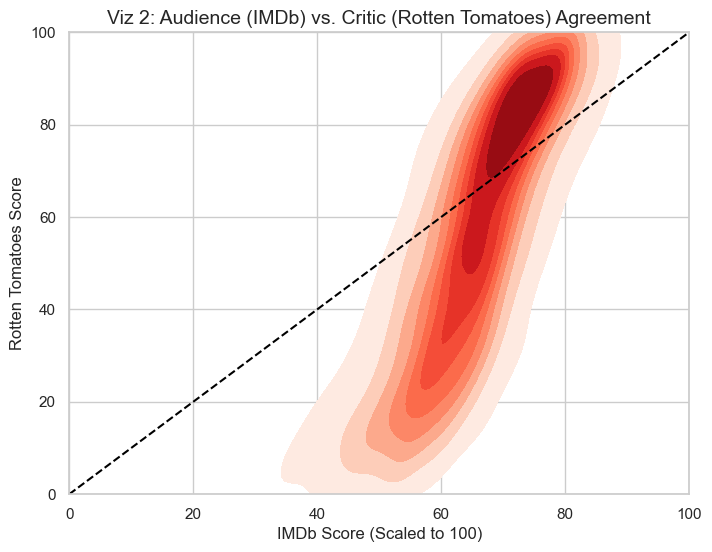

In [9]:
# =========================================================
# Visualization 2: Audience (IMDb) vs. Critic (Rotten Tomatoes) Agreement
# Type: Hexbin / Density Plot (Multi-Source)
# =========================================================
# Convert IMDb score (out of 10) to match Rotten Tomatoes (out of 100)
master_df['imdb_scaled'] = master_df['imdb_score'] * 10

# Drop rows with missing scores before KDE
kde_df = master_df[['imdb_scaled', 'rotten_tomatoes']].dropna()

plt.figure(figsize=(8, 6))
sns.kdeplot(
    data=kde_df,
    x='imdb_scaled',
    y='rotten_tomatoes',
    cmap="Reds",
    fill=True,
    clip=((0, 100), (0, 100))
)
plt.title('Viz 2: Audience (IMDb) vs. Critic (Rotten Tomatoes) Agreement', fontsize=14)
plt.xlabel('IMDb Score (Scaled to 100)')
plt.ylabel('Rotten Tomatoes Score')
# Plot a diagonal line showing where audience and critics agree perfectly
plt.plot([0, 100], [0, 100], color='black', linestyle='--')
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.show()


### Visualization 2 Interpretation

With visualization 2 the density plot acts like a heat map. The highest concentration of movies and where we see darker red areas. The dashed black line across the middle represents perfect agreement between audiences and critics - so any movie sitting exactly on that line means critics and audiences scored it identically. The dense red core sitting above and to the left of the diagonal tells us that for most of our movies in our dataset the Rotten Tomatoes scores tend to run higher than IMDb scores (after scaling).  The elongated oval shape shows the two scores are strongly correlated, but audiences (IMDb) tend to be a bit harsher or more moderate, while critics (RT) spread wider with scores that are a bit higher.


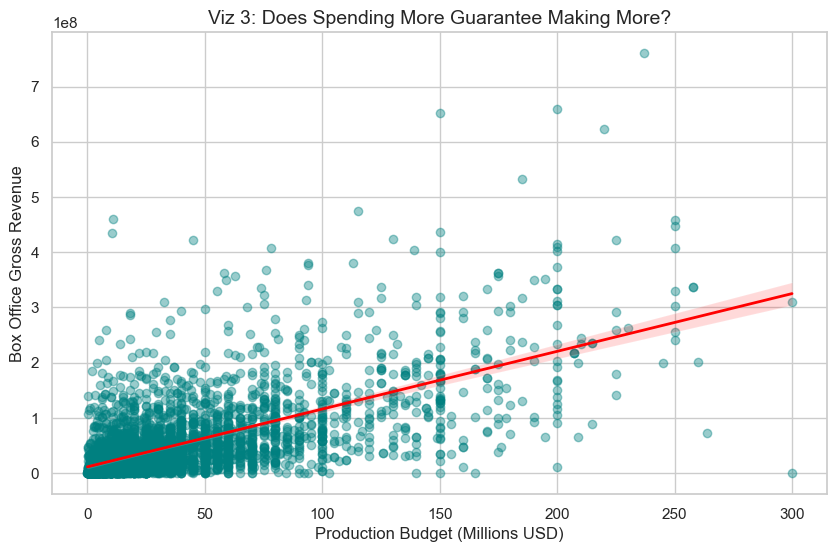

In [5]:
# =========================================================
# Visualization 3: The "Hollywood ROI" Core Question
# Type: Scatter Plot with Regression Line (Multi-Source)
# =========================================================
# Filter out extreme budget outliers (e.g., movies over $350M) to keep the chart readable
roi_trend_df = master_df[master_df['budget_millions'] < 350]

plt.figure(figsize=(10, 6))
sns.regplot(
    data=roi_trend_df, 
    x='budget_millions', 
    y='gross_revenue_csv', 
    scatter_kws={'alpha': 0.4, 'color': 'teal'}, 
    line_kws={'color': 'red', 'linewidth': 2}
)
plt.title('Viz 3: Does Spending More Guarantee Making More?', fontsize=14)
plt.xlabel('Production Budget (Millions USD)')
plt.ylabel('Box Office Gross Revenue')
plt.show()

### Visualization 3 Interpretation

This chart plots the Production Budget against Box Office Gross Revenue. The red line is a linear regression trendline showing the mathematical line of best fit. Since we have an upward-sloping red line, it indicates a positive correlation. So, for the most part, spending more money will get you those big bucks at the box office. We do have a number of dots though that fall far below the line—these are those notorious "Box Office Bombs" (high budget, not much to show for it). On the flip side, those dots that are soaring high above the line on the left side showcase those highly profitable "Indie Hits."

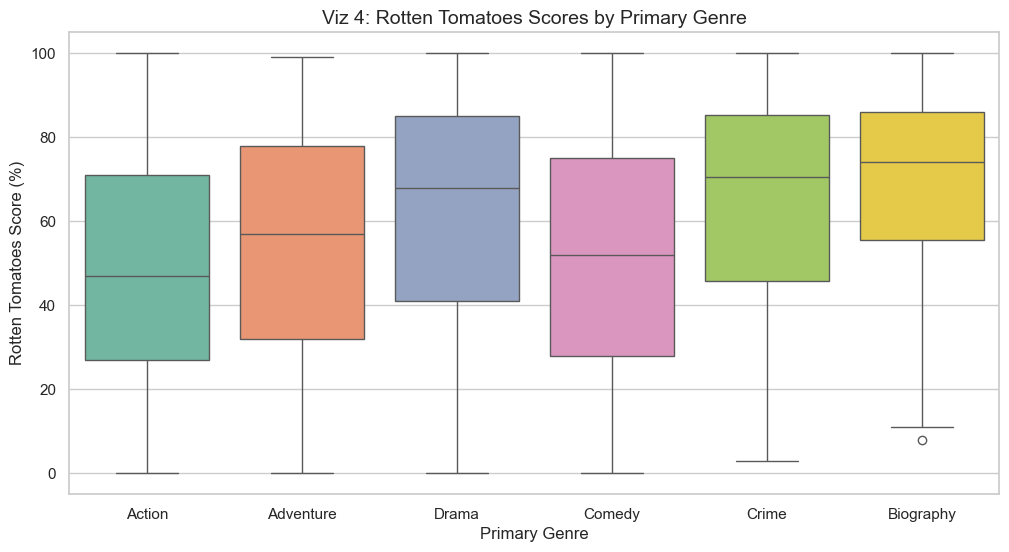

In [6]:
# =========================================================
# Visualization 4: Critic Scores by Primary Genre
# Type: Box Plot
# =========================================================
# Filter to the top 6 most common genres to keep the chart clean
top_genres = master_df['primary_genre'].value_counts().nlargest(6).index
genre_df = master_df[master_df['primary_genre'].isin(top_genres)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=genre_df, x='primary_genre', y='rotten_tomatoes', hue='primary_genre', palette='Set2', legend=False)
plt.title('Viz 4: Rotten Tomatoes Scores by Primary Genre', fontsize=14)
plt.xlabel('Primary Genre')
plt.ylabel('Rotten Tomatoes Score (%)')
plt.show()

### Visualization 4 Interpretation

Our Visualization 4 box-and-whisker plot shows the distribution of critic scores across the top 6 genres. The colored box represents the middle 50% of movies in that genre, and the horizontal line inside marks the median score. This gives us some insight to see if critics are biased toward certain genres. For example, if the box for "Drama" sits significantly higher on the y-axis than the box for "Action," it indicates that Dramas are generally received much better by critics. When we see boxes that are longer than the rest, it shows that the genre is all over the place and the quality is pretty inconsistent.

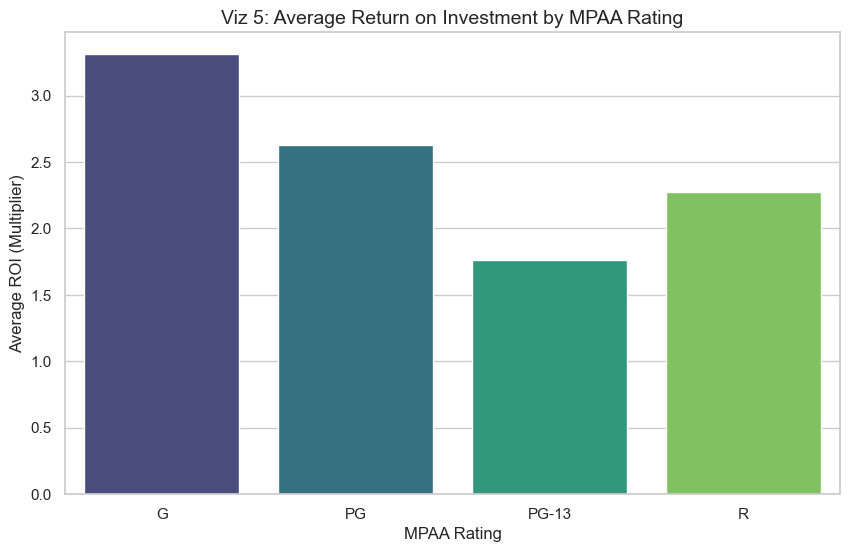


--- Final Consolidated Dataset (Human Readable) ---


,movie_title,director,budget_millions,gross_revenue_csv,imdb_score,roi,gross_revenue_wiki,wiki_all_time_rank,mpaa_rating,runtime_minutes,rotten_tomatoes,primary_genre,imdb_scaled
0,avatar,james cameron,237.0,760505847.0,7.9,3.21,2.923711e+09,1.0,PG-13,162.0,81.0,Action,79.0
1,pirates of the caribbean: at world's end,gore verbinski,300.0,309404152.0,7.1,1.03,NaN,NaN,PG-13,169.0,43.0,Action,71.0
2,spectre,sam mendes,245.0,200074175.0,6.8,0.82,NaN,NaN,PG-13,148.0,63.0,Action,68.0
3,the dark knight rises,christopher nolan,250.0,448130642.0,8.5,1.79,1.081170e+09,40.0,PG-13,164.0,87.0,Action,85.0
4,john carter,andrew stanton,263.7,73058679.0,6.6,0.28,NaN,NaN,PG-13,132.0,52.0,Action,66.0
5,spider-man 3,sam raimi,258.0,336530303.0,6.2,1.30,NaN,NaN,PG-13,139.0,63.0,Action,62.0
6,tangled,nathan greno,260.0,200807262.0,7.8,0.77,NaN,NaN,PG,100.0,89.0,Animation,78.0
7,avengers: age of ultron,joss whedon,250.0,458991599.0,7.5,1.84,1.402810e+09,19.0,PG-13,141.0,75.0,Action,75.0
8,harry potter and the half-blood prince,david yates,250.0,301956980.0,7.5,1.21,NaN,NaN,PG,153.0,83.0,Action,75.0
9,batman v superman: dawn of justice,zack snyder,250.0,330249062.0,6.9,1.32,NaN,NaN,R,151.0,28.0,Action,69.0


In [7]:
# =========================================================
# Visualization 5: Average ROI (CSV) by MPAA Rating (API)
# Type: Bar Chart (Multi-Source)
# =========================================================
# Filter out extreme outliers in ROI to get a clean average, and ignore unrated films
roi_df = master_df[(master_df['roi'] < 50) & (master_df['mpaa_rating'].isin(['G', 'PG', 'PG-13', 'R']))]
roi_avg = roi_df.groupby('mpaa_rating')['roi'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=roi_avg, x='mpaa_rating', y='roi', hue='mpaa_rating', order=['G', 'PG', 'PG-13', 'R'], palette='viridis', legend=False)
plt.title('Viz 5: Average Return on Investment by MPAA Rating', fontsize=14)
plt.xlabel('MPAA Rating')
plt.ylabel('Average ROI (Multiplier)')
plt.show()

# --- Print the Human Readable Dataset ---
print("\n--- Final Consolidated Dataset (Human Readable) ---")
display(master_df.head(15))

### Visualization 5 Interpretation

Visualization 5 is a simple bar chart that calculates the average ROI multiplier (Gross Revenue divided by Budget) grouped by age rating. Studio executives love charts like this, not only because they are simple, but because they reveal whether family-friendly movies (PG, PG-13) provide a higher percentage ROI compared to movies that have a smaller target audience thanks to their R-rating.

### Final Project Summary & Ethical Implications

This project was a joy to work on and it provided some great hands-on experience with the ETL (Extract, Transform, Load) pipeline. The trickiest part was trying to figure out a good subject that would have three different datasets that shared a key (Movie Title) we could utilize. It was an interesting journey that included handling messy web data using Pandas' string manipulation, navigating API rate limits, and constructing an SQLite database directly within Python to execute SQL JOIN commands. As usual, the visualizations revealed fantastic insights - such as the fact that higher budgets do not guarantee better critical reception, and that PG/PG-13 movies yield a higher average ROI than R-rated films.

Along the way we did have to make some changes to the data.  Massive text normalization was required to make the join work. Titles were converted to lowercase and stripped of whitespace/footnotes. Missing financial rows were dropped, currency symbols were removed using Regular Expressions, and API data was parsed to extract specific integers like runtime and Rotten Tomatoes scores.

Legal & Regulatory concerns that we can call out are that Wikipedia content is licensed under CC-BY-SA, which does permit scraping for educational use with attribution. We adhered to ethical scraping practices by using a 'User-Agent' header to identify the request as a legitimate browser and followed OMDb's Terms of Service and rate limits.  In addition, we also utilized a paid Patreon key to ethically manage the high volume of API requests without violating DoS policies, and utilized a Python time.sleep() function to ensure server stability.

A key assumption we made was that if a movie title from our CSV matched a title in the API, they were the exact same film. The problem with this is that it creates the risk of mismatched remakes (like The Mummy 1999 vs. 2017). There is also a notable risk introduced with our transformations referred to as 'Context Collapse'. In this instance, it surfaced when we isolated a single percentage (e.g., '82%'), causing us to lose the nuance of how many critics actually reviewed the film. We also assumed that dropping rows with missing budgets and missing Rotten Tomatoes scores was safe. However, doing this likely introduced survival bias; low-budget, independent, or foreign films are less likely to publicly report financials or be rated by Western critics, meaning the final dataset heavily leans towards major Hollywood productions.

To support the credibility of our data, we retrieved it from public sources that see a lot of traffic, which typically supports their credibility (this includes cross-referencing budgets found in Kaggle against IMDb and Box Office Mojo). We also made sure to document all our transformations in detail to mitigate ethical concerns and bias as much as we could. In the future, we could also look at including some additional data sources that would help us better represent some of those independent films.